# Análise Exploratória de Dados (EDA) — MVP Churn

Projeto de exploração e modelagem preditiva de churn utilizando o dataset **Telco Customer Churn**.

**Etapas:**
1. Carregamento dos Dados
2. Análise Exploratória Completa
3. Análise Geográfica de Churn
4. Feature Engineering
5. Pré-processamento e Limpeza
6. Encoding de Variáveis Categóricas
7. Modelagem — Random Forest
8. Seleção de Features
9. Comparação de Algoritmos e Tuning

In [ ]:
# EDA é analise exploratória de dados, é o processo de analisar e resumir os dados para entender suas características, 
# identificar padrões, detectar outliers e obter insights iniciais. A EDA é uma etapa crucial no processo de análise de dados, 
# pois ajuda a orientar as decisões sobre quais técnicas de modelagem ou análise aplicar posteriormente.
# Bibliotecas básicas
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
import openpyxl
# Estatística
from scipy import stats
# Carregar dataset do UCI Repository   


## 1. Carregamento dos Dados

Dataset com **7.043 clientes** e **33 colunas** cobrindo informações demográficas, serviços contratados e status de churn.
A variável target é `Churn Value` (0 = não cancelou, 1 = cancelou).

In [ ]:
df_churn = pd.read_csv("datasets/Telco_customer_churn.csv")
df_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [ ]:
df_churn = df_churn.drop(columns=['Count','CustomerID','Churn Reason'])

df_churn.head()

,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
0,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239
1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701
2,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372
3,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003
4,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340


## 2. Análise Exploratória

Função `analisar_dataframe()` executa 6 fases de análise:
1. Visão geral (shape, tipos, estatísticas descritivas)
2. Valores ausentes
3. Distribuições numéricas (histogramas + boxplots)
4. Distribuições categóricas
5. Matriz de correlação
6. Análise do target

In [ ]:
import math

def analisar_dataframe(df: pd.DataFrame, col_target: str | None = None, nome_dataset: str = 'Dataset', ignorar_colunas: list[str] | None = None) -> None:
    """
    Realiza uma análise exploratória inicial de um DataFrame.
    
    Parâmetros:
    -----------
    df : pd.DataFrame
        DataFrame a ser analisado.
    col_target : str, opcional
        Nome da coluna target para análise de distribuição.
    nome_dataset : str
        Nome do dataset para uso nos títulos dos gráficos.
    ignorar_colunas : list, opcional
        Lista de colunas a excluir da análise (ex: IDs, chaves).
    """
    cores_bin = ['#4C72B0', '#DD8452']
    sns.set_style('whitegrid')

    if ignorar_colunas is not None:
        colunas_validas = [c for c in ignorar_colunas if c in df.columns]
        df = df.drop(columns=colunas_validas)
        if colunas_validas:
            print(f"ℹ️  Colunas ignoradas: {colunas_validas}")

    # Tentativa de converter colunas object para numérico
    # Só converte se todos os valores não-nulos contiverem apenas números e espaços (sem letras)
   

    colunas_num = df.select_dtypes(include=[np.number]).columns.tolist()
    colunas_cat = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    # ─────────────────────────────────────────────
    # FASE 1 — Visão Geral
    # ─────────────────────────────────────────────
    print("=" * 60)
    print(f"  ANÁLISE EXPLORATÓRIA — {nome_dataset.upper()}")
    print("=" * 60)

    print(f"\n📐 Shape: {df.shape[0]} linhas × {df.shape[1]} colunas")
    print(f"\n🔢 Colunas numéricas ({len(colunas_num)}): {colunas_num}")
    print(f"🔤 Colunas categóricas ({len(colunas_cat)}): {colunas_cat}")

    print("\n─── Tipos de dados ───")
    print(df.dtypes.to_string())

    print("\n─── Estatísticas descritivas (numéricas) ───")
    print(df.describe().to_string())

    # ─────────────────────────────────────────────
    # FASE 2 — Valores Ausentes
    # ─────────────────────────────────────────────
    print("\n─── Valores ausentes ───")
    missing_count = df.isnull().sum()
    missing_pct = (missing_count / len(df)) * 100
    missing_df = pd.DataFrame({
        'Valores ausentes': missing_count,
        'Porcentagem (%)': missing_pct.round(2)
    }).sort_values('Porcentagem (%)', ascending=False)
    print(missing_df[missing_df['Valores ausentes'] > 0].to_string()
          if missing_df['Valores ausentes'].sum() > 0
          else "Nenhum valor ausente encontrado.")

    ausentes = missing_pct[missing_pct > 0].sort_values(ascending=False)
    if not ausentes.empty:
        fig, ax = plt.subplots(figsize=(10, max(3, len(ausentes) * 0.5 + 1)))
        sns.barplot(x=ausentes.values, y=ausentes.index, ax=ax, palette='Reds_r')
        ax.set_xlabel('% de valores ausentes')
        ax.set_title(f'Valores Ausentes por Coluna — {nome_dataset}', fontweight='bold')
        for i, v in enumerate(ausentes.values):
            ax.text(v + 0.3, i, f'{v:.1f}%', va='center')
        plt.tight_layout()
        plt.show()

    # ─────────────────────────────────────────────
    # FASE 3 — Distribuições Numéricas
    # ─────────────────────────────────────────────
    if colunas_num:
        ncols = 3
        nrows = math.ceil(len(colunas_num) / ncols)

        # Histogramas + KDE
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
        fig.suptitle(f'Distribuições Numéricas — {nome_dataset}', fontsize=14, fontweight='bold')
        axes_flat = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()
        for i, col in enumerate(colunas_num):
            sns.histplot(df[col].dropna(), kde=True, ax=axes_flat[i], color=cores_bin[0])
            axes_flat[i].set_title(col)
            axes_flat[i].set_xlabel('')
        for j in range(i + 1, len(axes_flat)):
            axes_flat[j].set_visible(False)
        plt.tight_layout()
        plt.show()

        # Boxplots
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
        fig.suptitle(f'Boxplots — {nome_dataset}', fontsize=14, fontweight='bold')
        axes_flat = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()
        for i, col in enumerate(colunas_num):
            sns.boxplot(y=df[col].dropna(), ax=axes_flat[i], color=cores_bin[0])
            axes_flat[i].set_title(col)
        for j in range(i + 1, len(axes_flat)):
            axes_flat[j].set_visible(False)
        plt.tight_layout()
        plt.show()

    # ─────────────────────────────────────────────
    # FASE 4 — Distribuições Categóricas
    # ─────────────────────────────────────────────
    if colunas_cat:
        ncols = 3
        nrows = math.ceil(len(colunas_cat) / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
        fig.suptitle(f'Distribuições Categóricas — {nome_dataset}', fontsize=14, fontweight='bold')
        axes_flat = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()
        for i, col in enumerate(colunas_cat):
            ordem = df[col].value_counts().index
            sns.countplot(data=df, y=col, order=ordem, ax=axes_flat[i], palette='Blues_d')
            axes_flat[i].set_title(col)
            axes_flat[i].set_xlabel('Contagem')
        for j in range(i + 1, len(axes_flat)):
            axes_flat[j].set_visible(False)
        plt.tight_layout()
        plt.show()

    # ─────────────────────────────────────────────
    # FASE 5 — Correlação
    # ─────────────────────────────────────────────
    if len(colunas_num) >= 2:
        corr = df[colunas_num].corr()
        fig, ax = plt.subplots(figsize=(max(6, len(colunas_num) * 0.8), max(5, len(colunas_num) * 0.7)))
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                    linewidths=0.5, ax=ax)
        ax.set_title(f'Correlação entre Variáveis Numéricas — {nome_dataset}', fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ─────────────────────────────────────────────
    # FASE 6 — Análise do Target (opcional)
    # ─────────────────────────────────────────────
    if col_target and col_target in df.columns:
        target = df[col_target]
        n_unique = target.nunique()

        print(f"\n─── Distribuição do target: '{col_target}' ───")
        df_dist = pd.DataFrame({
            "Volume": target.value_counts(),
            "Porcentagem": (target.value_counts(normalize=True) * 100).round(2).astype(str) + '%'
        })
        print(df_dist.to_string())

        # Binarizar se mais de 2 valores únicos
        if n_unique > 2:
            mediana = target.median()
            target_plot = (target > mediana).astype(int)
            label_neg = f'≤ {mediana} (0)'
            label_pos = f'> {mediana} (1+)'
        else:
            target_plot = target
            vals = sorted(target.unique())
            label_neg = str(vals[0])
            label_pos = str(vals[1]) if len(vals) > 1 else str(vals[0])

        bin_counts = target_plot.value_counts().sort_index()
        labels = [label_neg, label_pos] if len(bin_counts) == 2 else [str(k) for k in bin_counts.index]

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f"Análise do Target: '{col_target}' — {nome_dataset}", fontsize=14, fontweight='bold')

        # Contagem original
        orig = target.value_counts().sort_index()
        axes[0].bar(orig.index.astype(str), orig.values, color=sns.color_palette('Blues_d', len(orig)))
        axes[0].set_title('Contagem por valor (original)')
        axes[0].set_xlabel(col_target)
        axes[0].set_ylabel('Contagem')
        for idx, v in enumerate(orig.values):
            axes[0].text(idx, v + 0.5, str(v), ha='center', fontweight='bold')

        # Pizza
        axes[1].pie(bin_counts.values, labels=labels, autopct='%1.1f%%',
                    colors=cores_bin[:len(bin_counts)], startangle=90)
        axes[1].set_title('Proporção das Classes')

        # Barras binárias
        axes[2].bar(labels, bin_counts.values, color=cores_bin[:len(bin_counts)])
        axes[2].set_title('Contagem das Classes')
        axes[2].set_ylabel('Contagem')
        for idx, v in enumerate(bin_counts.values):
            axes[2].text(idx, v + 0.5, str(v), ha='center', fontweight='bold')

        plt.tight_layout()
        plt.show()

    print("\n✅ Análise concluída.")


ℹ️  Colunas ignoradas: ['Churn Label']
  ANÁLISE EXPLORATÓRIA — TELCO CUSTOMER CHURN

📐 Shape: 7043 linhas × 29 colunas

🔢 Colunas numéricas (8): ['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
🔤 Colunas categóricas (21): ['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges']

─── Tipos de dados ───
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service   

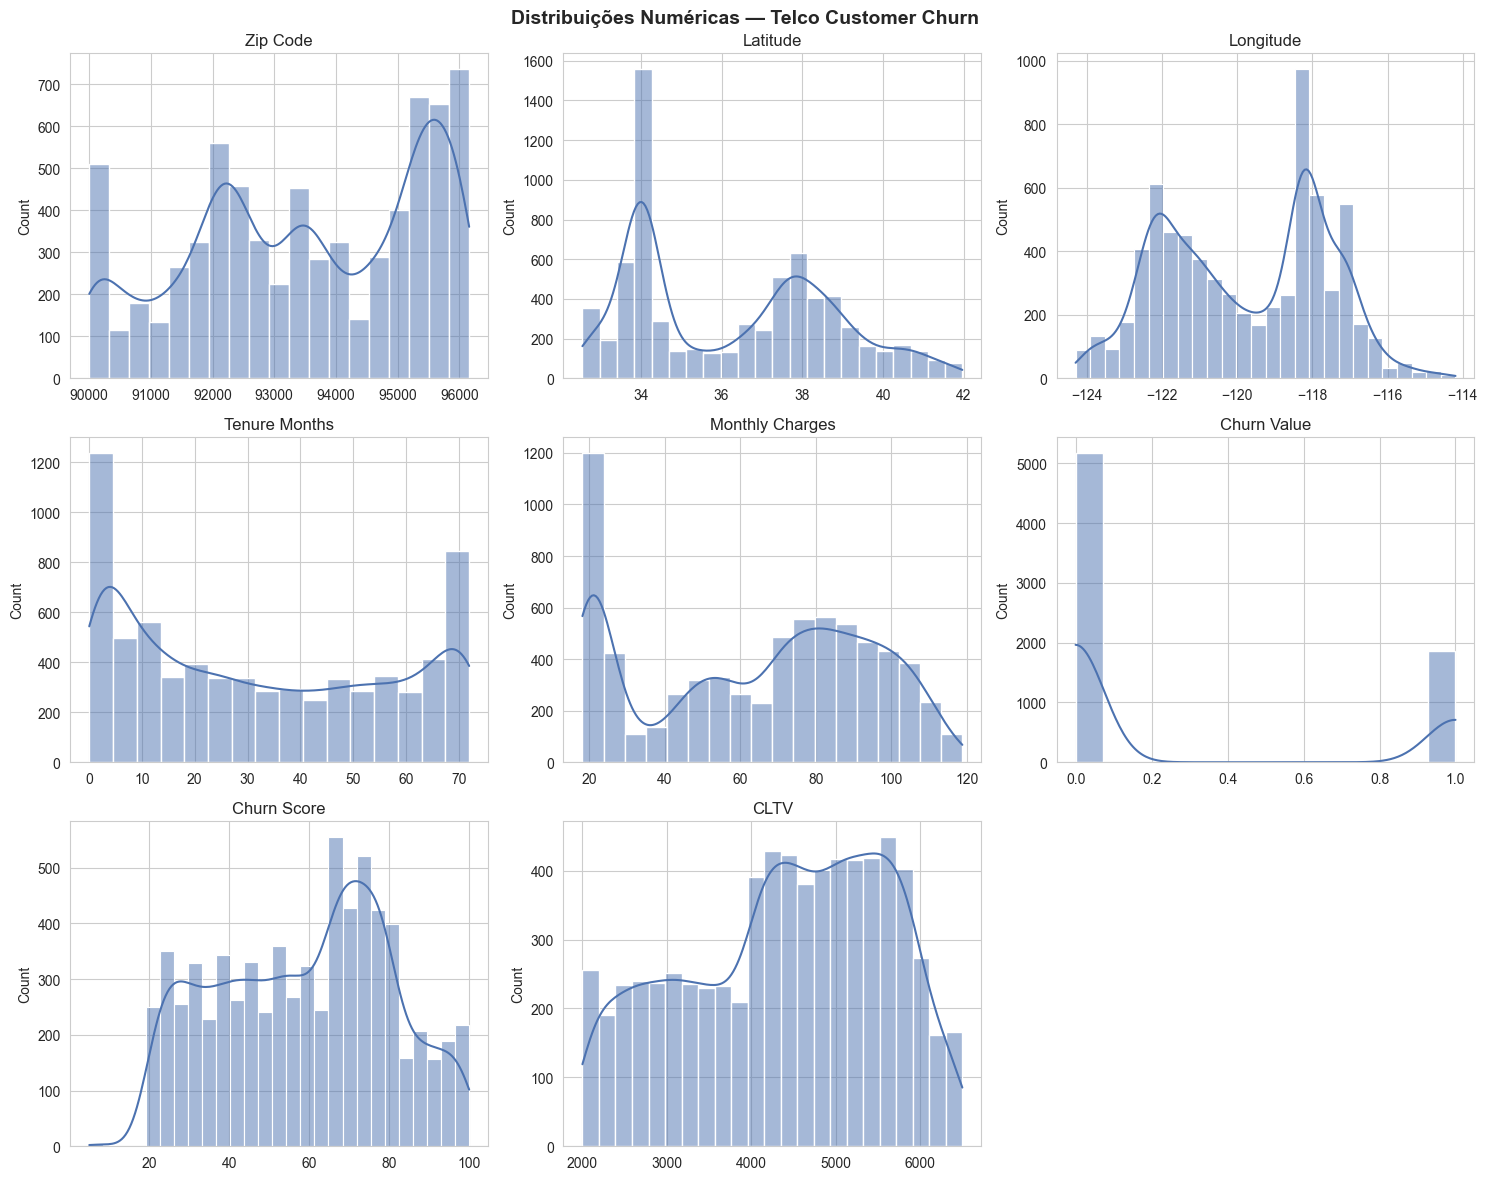

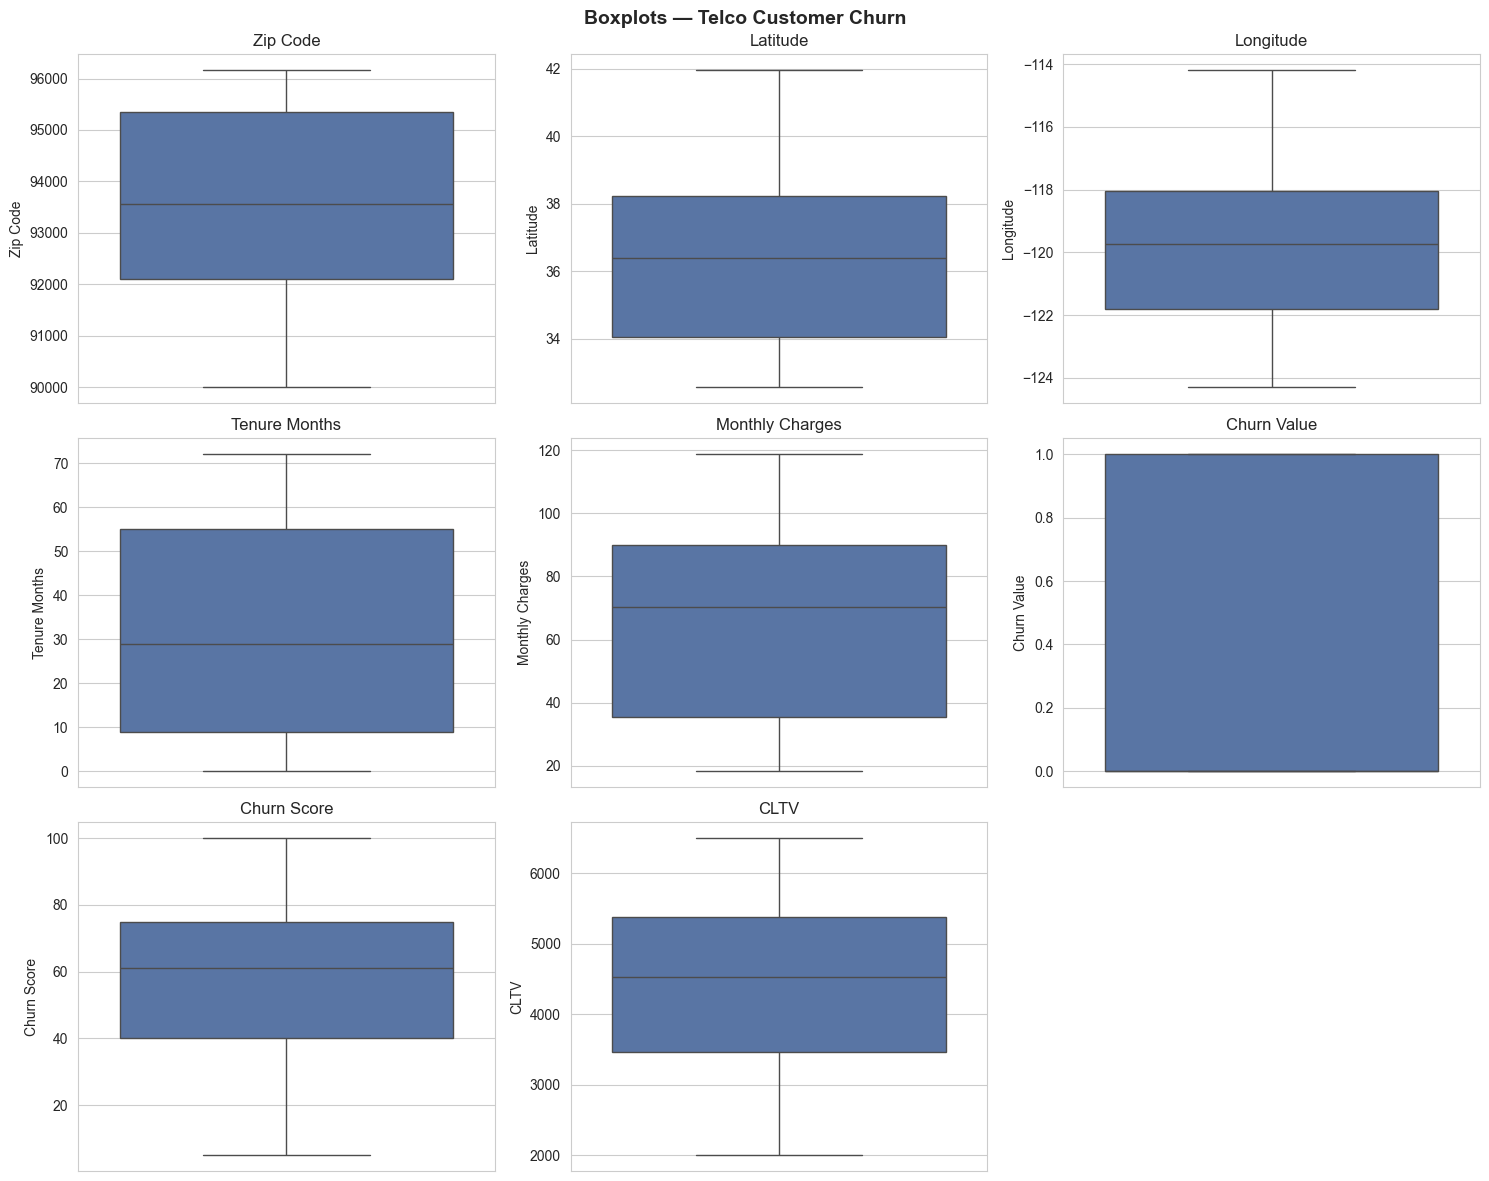

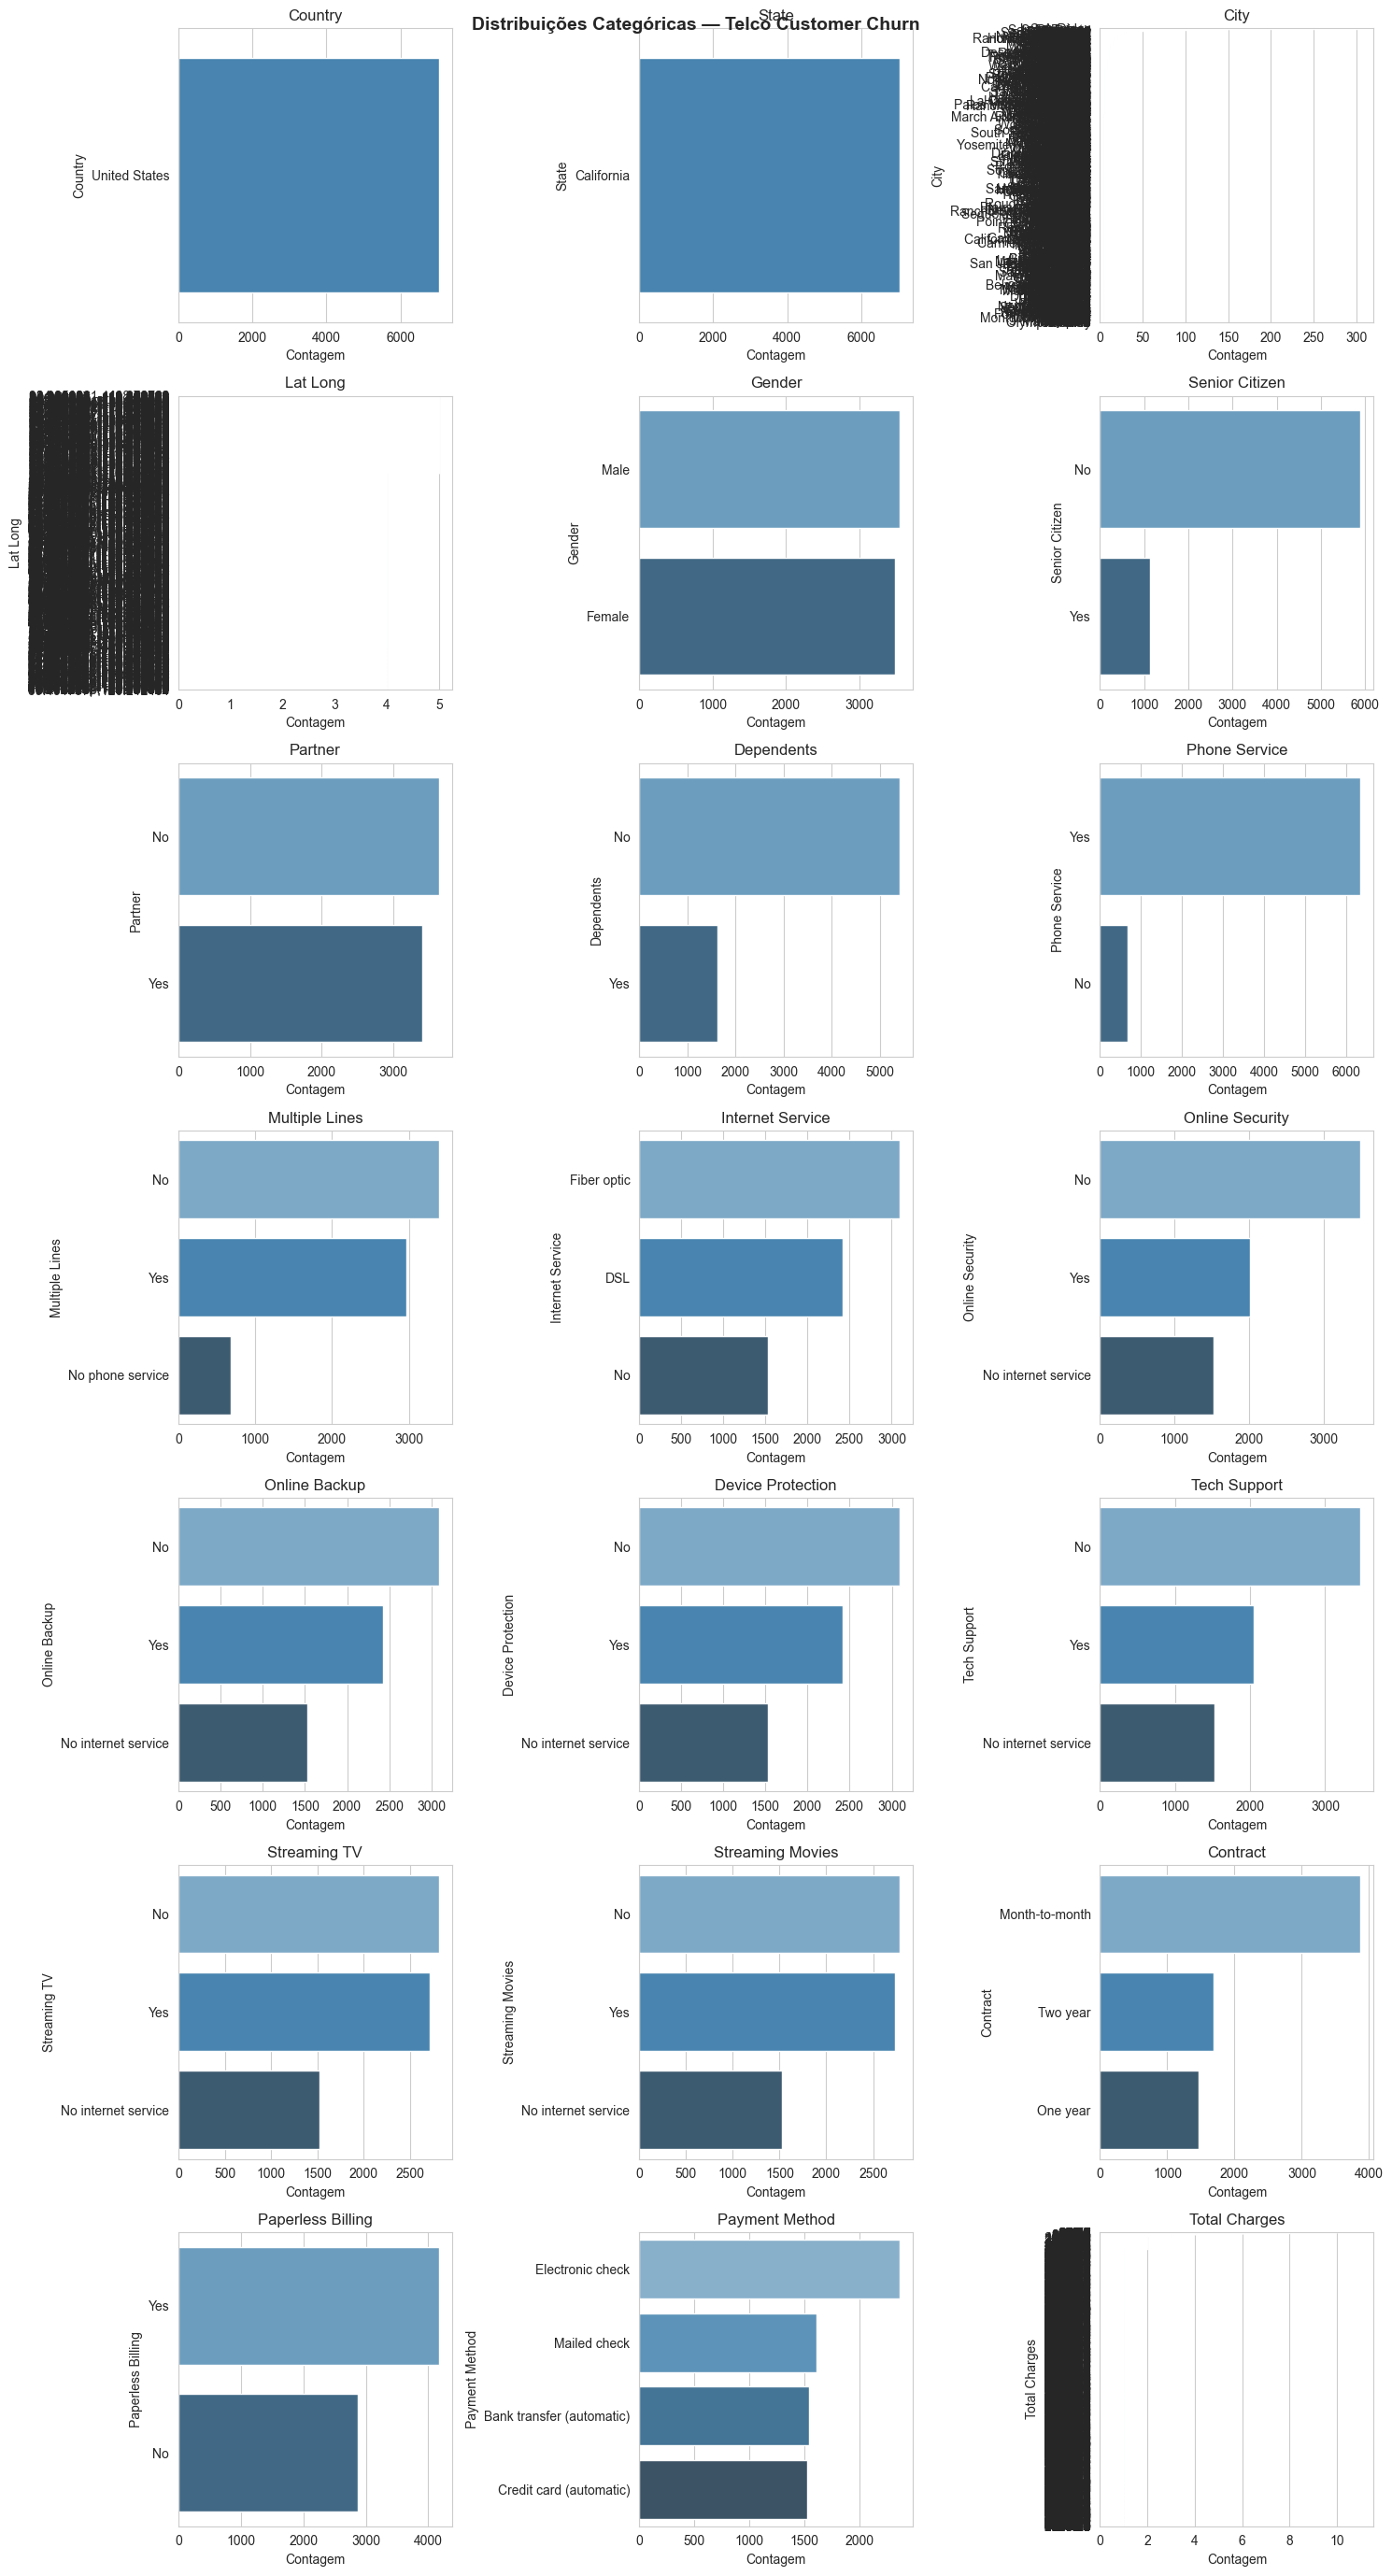

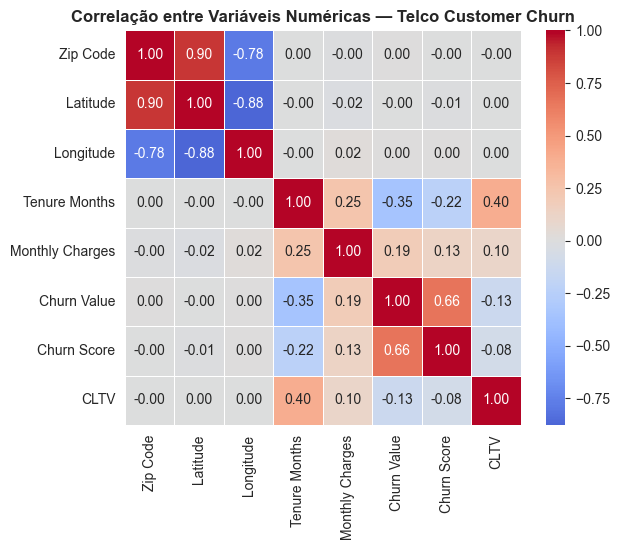


─── Distribuição do target: 'Churn Value' ───
             Volume Porcentagem
Churn Value                    
0              5174      73.46%
1              1869      26.54%


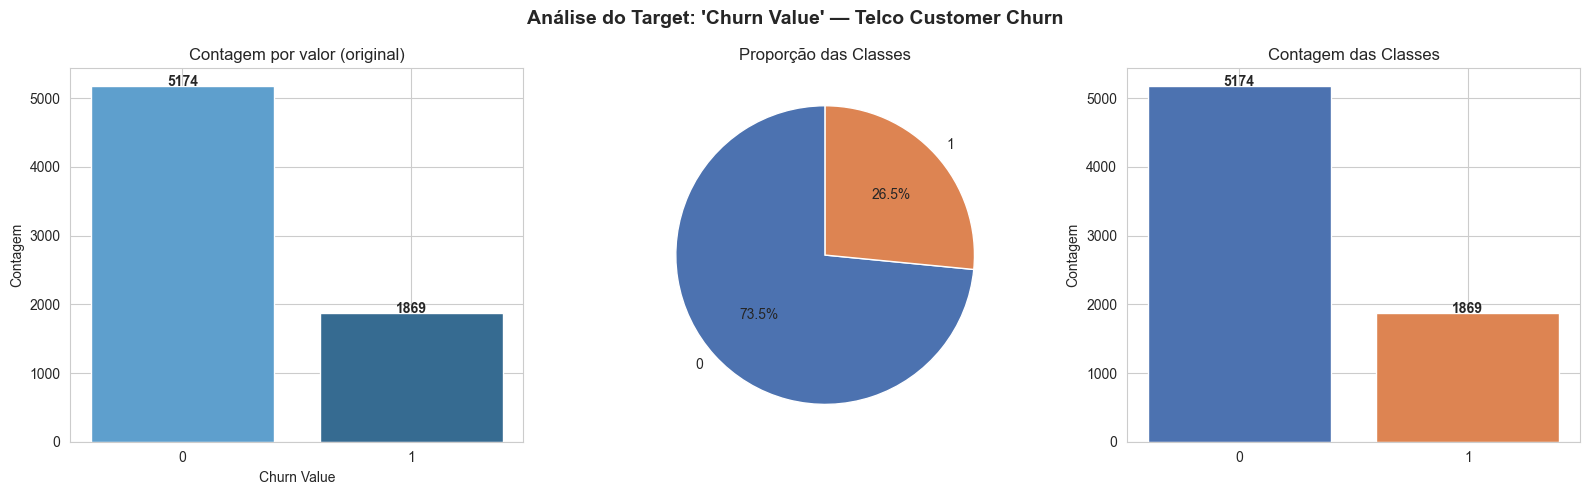


✅ Análise concluída.


In [ ]:
# Exemplo de uso — Heart Disease
analisar_dataframe(df_churn, col_target='Churn Value', nome_dataset='Telco Customer Churn', ignorar_colunas=['CustomerID',"Count","Churn Label"])


## 3. Análise Geográfica de Churn

Investigação da distribuição de churn por cidade: taxa de cancelamento, volume de churners e percentual em relação à base local de cada cidade.

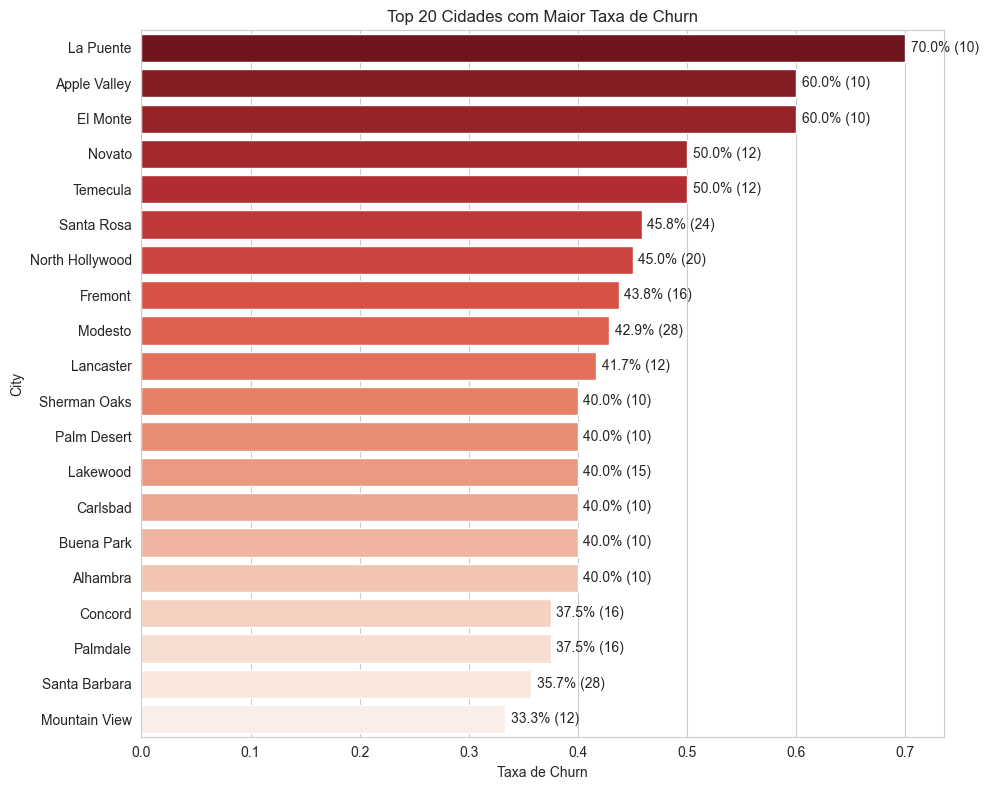

In [ ]:
churn_por_cidade = (
    df_churn.groupby('City')['Churn Value']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'taxa_churn', 'count': 'total'})
    .query('total >= 10')          # remove cidades com poucos clientes (ruído)
    .sort_values('taxa_churn', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x='taxa_churn', y=churn_por_cidade.index, data=churn_por_cidade,
            palette='Reds_r', ax=ax)
ax.set_xlabel('Taxa de Churn')
ax.set_title('Top 20 Cidades com Maior Taxa de Churn')

# Anotar com total de clientes
for i, (taxa, total) in enumerate(zip(churn_por_cidade['taxa_churn'], churn_por_cidade['total'])):
    ax.text(taxa + 0.005, i, f'{taxa:.1%} ({total})', va='center')

plt.tight_layout()
plt.show()

In [ ]:
total_por_cidade = df_churn.groupby('City').size().reset_index(name='total_clientes')

churn_por_cidade = (
    df_churn[df_churn['Churn Value'] == 1]
    .groupby('City')
    .size()
    .reset_index(name='total_churn')
    .merge(total_por_cidade, on='City')
    .assign(pct_churn=lambda x: (x['total_churn'] / x['total_clientes'] * 100).round(2))
    .sort_values('total_clientes', ascending=False)
)
churn_por_cidade

,City,total_churn,total_clientes,pct_churn
417,Los Angeles,90,305,29.51
638,San Diego,50,150,33.33
645,San Jose,29,112,25.89
629,Sacramento,26,108,24.07
641,San Francisco,31,104,29.81
...,...,...,...,...
819,Wofford Heights,1,4,25.00
818,Witter Springs,1,4,25.00
817,Winton,1,4,25.00
816,Winters,2,4,50.00


## 4. Feature Engineering

Criação de novas features combinando colunas existentes para capturar padrões mais ricos:

| Feature | Descrição | Churn Rate |
|---------|-----------|------------|
| `high_risk_profile` | Fiber optic + Month-to-month | **54.6%** |
| `isolated_senior` | Idoso sem Partner e sem Dependents | **48.9%** |
| `internet_services_count` | Qtd. de serviços de internet contratados | inversamente proporcional |
| `charge_per_tenure_month` | Monthly Charges / (Tenure Months + 1) | 3.2x maior em churners |

In [ ]:
# 1. Combo de maior risco
df_churn['high_risk_profile'] = (
    (df_churn['Internet Service'] == 'Fiber optic') & 
    (df_churn['Contract'] == 'Month-to-month')
).astype(int)

# 2. Perfil vulnerável
df_churn['isolated_senior'] = (
    (df_churn['Senior Citizen'] == 'Yes') & 
    (df_churn['Partner'] == 'No') & 
    (df_churn['Dependents'] == 'No')
).astype(int)

# 3. Engajamento com serviços
servicos = ['Online Security','Online Backup','Device Protection',
            'Tech Support','Streaming TV','Streaming Movies']
df_churn['internet_services_count'] = sum((df_churn[c] == 'Yes').astype(int) for c in servicos)

# 4. Custo relativo ao tempo de permanência
df_churn['cost_per_month'] = df_churn['Monthly Charges'] / (df_churn['Tenure Months'] + 1)

## 5. Pré-processamento e Limpeza

- Conversão de colunas `object` para `float` onde aplicável
- Tratamento de `Total Charges` (armazenado como string com espaços)
- Imputação de valores ausentes com a mediana

In [ ]:
def converter_para_float(df):
    """
    Tenta converter cada coluna do DataFrame para float.
    Converte apenas as colunas que forem totalmente conversíveis (sem erros).
    Retorna um novo DataFrame com as colunas convertidas.
    """
    df = df.copy()
    convertidas = []
    nao_convertidas = []

    for col in df.columns:
        if df[col].dtype == 'float64':
            continue
        try:
            df[col] = pd.to_numeric(df[col], errors='raise').astype(float)
            convertidas.append(col)
        except (ValueError, TypeError):
            nao_convertidas.append(col)

    print(f"Colunas convertidas para float: {convertidas}")
    print(f"Colunas não convertidas: {nao_convertidas}")
    return df

data_float = converter_para_float(df_churn)
data_float.dtypes


Colunas convertidas para float: ['Zip Code', 'Tenure Months', 'Churn Value', 'Churn Score', 'CLTV', 'high_risk_profile', 'isolated_senior', 'internet_services_count']
Colunas não convertidas: ['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn Label']


Country                        str
State                          str
City                           str
Zip Code                   float64
Lat Long                       str
Latitude                   float64
Longitude                  float64
Gender                         str
Senior Citizen                 str
Partner                        str
Dependents                     str
Tenure Months              float64
Phone Service                  str
Multiple Lines                 str
Internet Service               str
Online Security                str
Online Backup                  str
Device Protection              str
Tech Support                   str
Streaming TV                   str
Streaming Movies               str
Contract                       str
Paperless Billing              str
Payment Method                 str
Monthly Charges            float64
Total Charges                  str
Churn Label                    str
Churn Value                float64
Churn Score         

In [ ]:
df_churn["Total Charges"] = pd.to_numeric(df_churn["Total Charges"], errors='coerce')

In [ ]:
df_churn['Total Charges'] = df_churn['Total Charges'].fillna(df_churn['Total Charges'].median(), inplace=True)

In [ ]:
df_churn['Total Charges'].describe()

count    7043.000000
mean     2281.916928
std      2265.270398
min        18.800000
25%       402.225000
50%      1397.475000
75%      3786.600000
max      8684.800000
Name: Total Charges, dtype: float64

## 6. Encoding de Variáveis Categóricas

Aplicação de **One-Hot Encoding** nas colunas categóricas. Colunas geográficas removidas antes do encoding:

- **`City`** — 833 valores únicos (explosão de dimensionalidade)
- **`Country`** — zero variância (todos os registros são "United States")
- **`Lat Long`, `Latitude`, `Longitude`, `Zip Code`** — redundantes com `State`
- **`State`** mantido para representar a dimensão geográfica

In [ ]:
def one_hot_encode_categoricas(df):
    """
    Aplica one-hot encoding em todas as colunas categóricas do DataFrame.
    Retorna um novo DataFrame com as colunas originais substituídas.
    """
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)
    bool_cols = df_encoded.select_dtypes(include=bool).columns
    df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
    print(f"Colunas categóricas codificadas: {cat_cols}")
    print(f"Shape original: {df.shape} → Shape após encoding: {df_encoded.shape}")
    return df_encoded

# Colunas de data leakage (informação que deriva do target)
colunas_vazar = ['Churn Score', 'CLTV', 'Churn Label']

# Colunas geográficas: City tem 833 valores únicos → causa explosão de dimensionalidade.
# Mantemos apenas State para representar a dimensão geográfica.
# Country é descartado pois todos os registros são "United States" (zero variância).
# Lat Long, Latitude, Longitude e Zip Code são redundantes com State neste contexto.
colunas_geograficas = ['City', 'Country', 'Lat Long', 'Latitude', 'Longitude', 'Zip Code']

colunas_drop = colunas_vazar + colunas_geograficas
df_churn = df_churn.drop(columns=[c for c in colunas_drop if c in df_churn.columns])

print(f"Shape após remoção das colunas geográficas e leakage: {df_churn.shape}")
print(f"States únicos mantidos para encoding: {df_churn['State'].nunique()}")

data_encoded = one_hot_encode_categoricas(df_churn)
data_encoded.head()

Shape após remoção das colunas geográficas e leakage: (7043, 25)
States únicos mantidos para encoding: 1
Colunas categóricas codificadas: ['State', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Shape original: (7043, 25) → Shape após encoding: (7043, 52)


,Tenure Months,Monthly Charges,Total Charges,Churn Value,high_risk_profile,isolated_senior,internet_services_count,cost_per_month,State_California,Gender_Female,...,Streaming Movies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,Paperless Billing_No,Paperless Billing_Yes,Payment Method_Bank transfer (automatic),Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,0,0,2,17.950000,1,0,...,0,1,0,0,0,1,0,0,0,1
1,2,70.70,151.65,1,1,0,0,23.566667,1,1,...,0,1,0,0,0,1,0,0,1,0
2,8,99.65,820.50,1,1,0,3,11.072222,1,1,...,1,1,0,0,0,1,0,0,1,0
3,28,104.80,3046.05,1,1,0,4,3.613793,1,1,...,1,1,0,0,0,1,0,0,1,0
4,49,103.70,5036.30,1,1,0,4,2.074000,1,0,...,1,1,0,0,0,1,1,0,0,0


In [ ]:
data_encoded.dtypes

Tenure Months                                 int64
Monthly Charges                             float64
Total Charges                               float64
Churn Value                                   int64
high_risk_profile                             int64
isolated_senior                               int64
internet_services_count                       int64
cost_per_month                              float64
State_California                              int64
Gender_Female                                 int64
Gender_Male                                   int64
Senior Citizen_No                             int64
Senior Citizen_Yes                            int64
Partner_No                                    int64
Partner_Yes                                   int64
Dependents_No                                 int64
Dependents_Yes                                int64
Phone Service_No                              int64
Phone Service_Yes                             int64
Multiple Lin

## 7. Modelagem — Random Forest

Modelo baseline com **RandomForestClassifier** para predição de churn.

- Split estratificado: 80% treino / 20% teste
- Avaliação: Classification Report, Matriz de Confusão e ROC-AUC
- Feature importance para identificar as variáveis mais relevantes

Número de features disponíveis: 51
Colunas: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'high_risk_profile', 'isolated_senior', 'internet_services_count', 'cost_per_month', 'State_California', 'Gender_Female', 'Gender_Male', 'Senior Citizen_No', 'Senior Citizen_Yes', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'Phone Service_No', 'Phone Service_Yes', 'Multiple Lines_No', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_DSL', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_No', 'Online Security_No internet service', 'Online Security_Yes', 'Online Backup_No', 'Online Backup_No internet service', 'Online Backup_Yes', 'Device Protection_No', 'Device Protection_No internet service', 'Device Protection_Yes', 'Tech Support_No', 'Tech Support_No internet service', 'Tech Support_Yes', 'Streaming TV_No', 'Streaming TV_No internet service', 'Streaming TV_Yes', 'Streaming Movies_No', 'Streaming Movies_No internet servi

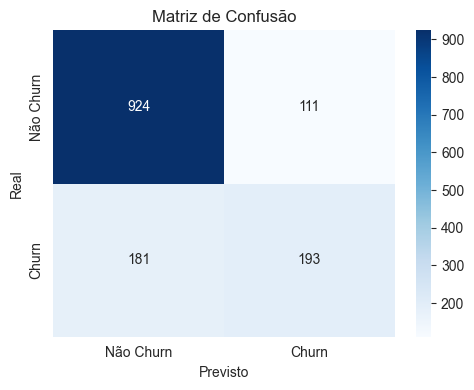

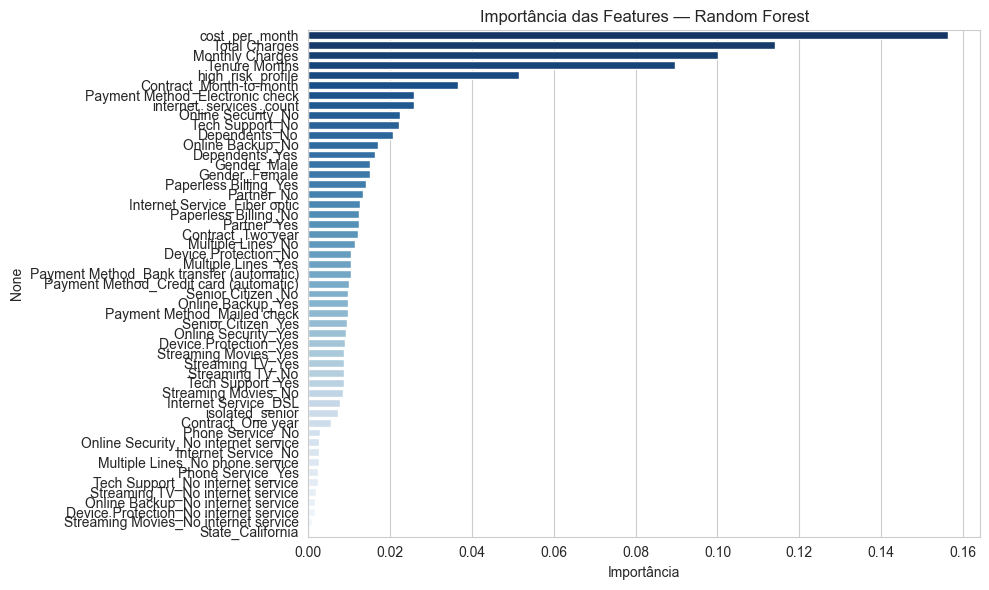

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ── Preparação dos dados ──────────────────────────────────────────
# get_dummies gera colunas bool em pandas recentes — converter para int
df_model = data_encoded.copy()

# Manter apenas colunas numéricas
df_model = df_model.select_dtypes(include=[np.number])

X = df_model.drop(columns=['Churn Value'])
y = df_model['Churn Value']

# Preencher eventuais nulos restantes com a mediana
X = X.fillna(X.median())

print(f"Número de features disponíveis: {X.shape[1]}")
print(f"Colunas: {X.columns.tolist()}")

# ── Split treino / teste ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modelo MVP: Random Forest ─────────────────────────────────────
modelo = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo.fit(X_train, y_train)

# ── Avaliação ─────────────────────────────────────────────────────
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

print("=== Relatório de Classificação ===")
print(classification_report(y_test, y_pred, target_names=['Não Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# ── Matriz de Confusão ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Não Churn', 'Churn'],
            yticklabels=['Não Churn', 'Churn'], ax=ax)
ax.set_xlabel('Previsto')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão')
plt.tight_layout()
plt.show()

# ── Feature Importance ────────────────────────────────────────────
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=importancias.values, y=importancias.index, palette='Blues_r', ax=ax)
ax.set_title('Importância das Features — Random Forest')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.show()


## 8. Seleção de Features

Comparação entre **7 métodos** de seleção com ranking agregado final:

| # | Método | Tipo |
|---|--------|------|
| 1 | SelectKBest (ANOVA F-score) | Filter |
| 2 | SelectKBest (Chi-quadrado) | Filter |
| 3 | Informação Mútua | Filter |
| 4 | Correlação de Pearson | Filter |
| 5 | Random Forest Feature Importance | Embedded |
| 6 | RFE com Regressão Logística | Wrapper |
| 7 | SelectFromModel (RF, limiar=média) | Embedded |

O **ranking agregado** normaliza os scores de todos os métodos para uma seleção robusta das top K features.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SelectKBest (f_classif / ANOVA) — Top 30 features
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
high_risk_profile                        1249.086825
Contract_Month-to-month                  1114.220194
cost_per_month                           1111.400335
Online Security_No                        767.858645
Tenure Months                             763.890183
Tech Support_No                           731.768357
Internet Service_Fiber optic              610.199922
Payment Method_Electronic check           595.424491
Contract_Two year                         566.070664
Online Backup_No                          440.506349
Dependents_Yes                            388.278936
Dependents_No                             388.278936
Device Protection_No                      371.446887
Streaming TV_No internet service          311.490238
Streaming Movies_No internet service      311.490238
Internet Service_No                      

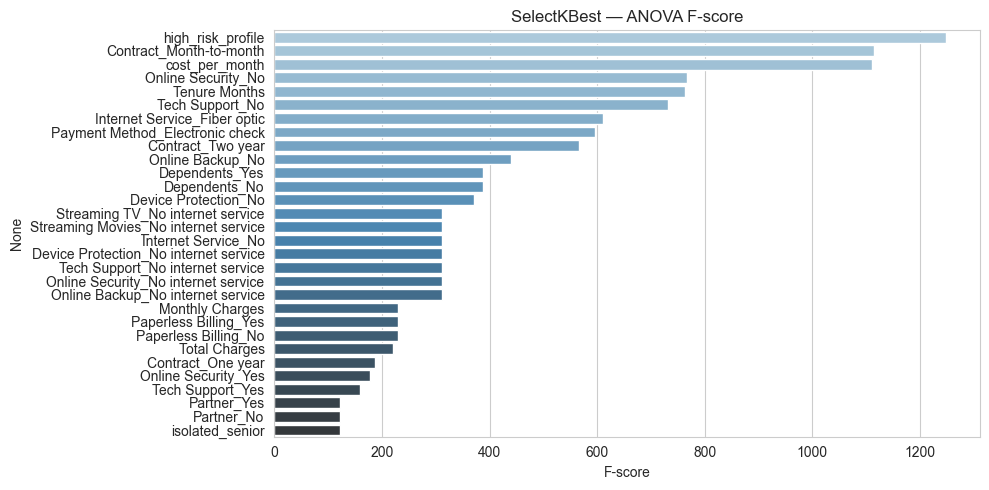


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SelectKBest (chi2) — Top 30 features
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
high_risk_profile                           712.847271
Contract_Month-to-month                     418.190550
Contract_Two year                           390.436350
Payment Method_Electronic check             357.880512
Online Security_No                          340.384858
Tech Support_No                             329.215755
Internet Service_Fiber optic                308.022809
Dependents_Yes                              279.457588
Internet Service_No                         231.646187
Tech Support_No internet service            231.646187
Streaming Movies_No internet service        231.646187
Online Backup_No internet service           231.646187
Device Protection_No internet service       231.646187
Online Security_No internet service         231.646187
Streaming TV_No internet service            231.646187
Online Backup_No       

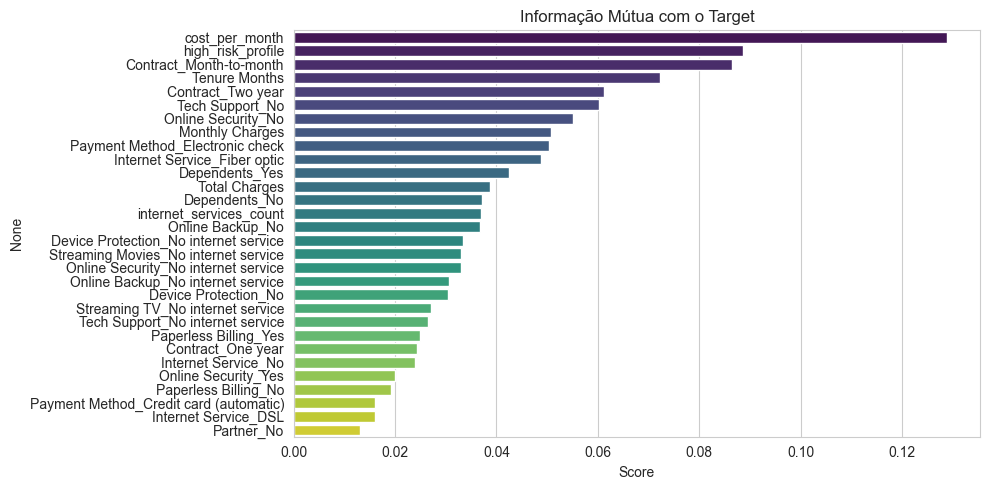


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Correlação de Pearson |r| com o target — Top 30
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
high_risk_profile                        0.426057
Contract_Month-to-month                  0.406401
cost_per_month                           0.405972
Online Security_No                       0.346382
Tenure Months                            0.345593
Tech Support_No                          0.339101
Internet Service_Fiber optic             0.312656
Payment Method_Electronic check          0.309214
Contract_Two year                        0.302209
Online Backup_No                         0.269335
Dependents_No                            0.253959
Dependents_Yes                           0.253959
Device Protection_No                     0.248741
Streaming TV_No internet service         0.228929
Streaming Movies_No internet service     0.228929
Internet Service_No                      0.228929
Device Protection_No internet service

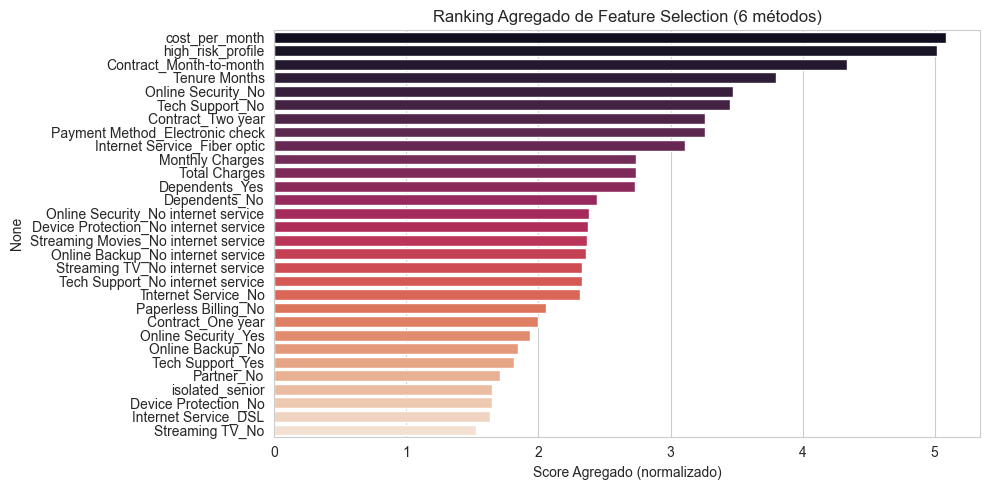


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Resumo das Top 30 features por método
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,ANOVA F,Chi2,Inf. Mútua,Correlação,RF Importance,RFE Ranking,Score Agr.
cost_per_month,1111.40,175.32,0.1290,0.4060,0.1564,1,5.0883
high_risk_profile,1249.09,712.85,0.0886,0.4261,0.0515,1,5.0159
Contract_Month-to-month,1114.22,418.19,0.0864,0.4064,0.0367,1,4.3367
Tenure Months,763.89,173.63,0.0724,0.3456,0.0896,1,3.7992
Online Security_No,767.86,340.38,0.0550,0.3464,0.0224,1,3.4746
Tech Support_No,731.77,329.22,0.0602,0.3391,0.0223,1,3.4515
Contract_Two year,566.07,390.44,0.0612,0.3022,0.0121,1,3.2604
Payment Method_Electronic check,595.42,357.88,0.0504,0.3092,0.0259,1,3.2593
Internet Service_Fiber optic,610.20,308.02,0.0487,0.3127,0.0126,1,3.1117
Monthly Charges,229.90,42.98,0.0508,0.1980,0.1002,1,2.7414



✔ Features selecionadas para o modelo (30):
['cost_per_month', 'high_risk_profile', 'Contract_Month-to-month', 'Tenure Months', 'Online Security_No', 'Tech Support_No', 'Contract_Two year', 'Payment Method_Electronic check', 'Internet Service_Fiber optic', 'Monthly Charges', 'Total Charges', 'Dependents_Yes', 'Dependents_No', 'Online Security_No internet service', 'Device Protection_No internet service', 'Streaming Movies_No internet service', 'Online Backup_No internet service', 'Streaming TV_No internet service', 'Tech Support_No internet service', 'Internet Service_No', 'Paperless Billing_No', 'Contract_One year', 'Online Security_Yes', 'Online Backup_No', 'Tech Support_Yes', 'Partner_No', 'isolated_senior', 'Device Protection_No', 'Internet Service_DSL', 'Streaming TV_No']

Shape original: (5634, 51)  →  Shape reduzido: (5634, 30)


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# SELEÇÃO DE FEATURES — Comparação entre múltiplos métodos
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.feature_selection import (
    SelectKBest, chi2, mutual_info_classif, f_classif,
    RFE, SelectFromModel
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# ── Pré-requisito: X e y sem nulos, X com valores ≥ 0 para chi2 ──────────────
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

K = 30   # Número de features desejado — ajuste conforme necessário

# ══════════════════════════════════════════════════════════════════════════════
# 1. FILTER — SelectKBest com f_classif (ANOVA F-score)
# ══════════════════════════════════════════════════════════════════════════════
skb_f = SelectKBest(score_func=f_classif, k=K)
skb_f.fit(X_scaled, y_train)
skb_f_features = X_train.columns[skb_f.get_support()].tolist()
anova_scores = pd.Series(skb_f.scores_, index=X_train.columns).sort_values(ascending=False)

print("━" * 55)
print(f"  SelectKBest (f_classif / ANOVA) — Top {K} features")
print("━" * 55)
print(anova_scores.head(K).to_string())
print(f"\nFeatures selecionadas: {skb_f_features}")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=anova_scores.head(K).values, y=anova_scores.head(K).index,
            palette='Blues_d', ax=ax)
ax.set_title('SelectKBest — ANOVA F-score')
ax.set_xlabel('F-score')
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 2. FILTER — SelectKBest com chi2 (qui-quadrado, requer X ≥ 0)
# ══════════════════════════════════════════════════════════════════════════════
skb_chi2 = SelectKBest(score_func=chi2, k=K)
skb_chi2.fit(X_scaled, y_train)
skb_chi2_features = X_train.columns[skb_chi2.get_support()].tolist()
chi2_scores = pd.Series(skb_chi2.scores_, index=X_train.columns).sort_values(ascending=False)

print("\n" + "━" * 55)
print(f"  SelectKBest (chi2) — Top {K} features")
print("━" * 55)
print(chi2_scores.head(K).to_string())
print(f"\nFeatures selecionadas: {skb_chi2_features}")

# ══════════════════════════════════════════════════════════════════════════════
# 3. FILTER — Informação Mútua
# ══════════════════════════════════════════════════════════════════════════════
mi = mutual_info_classif(X_scaled, y_train, random_state=42)
mi_scores = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)

print("\n" + "━" * 55)
print(f"  Informação Mútua — Top {K} features")
print("━" * 55)
print(mi_scores.head(K).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=mi_scores.head(K).values, y=mi_scores.head(K).index,
            palette='viridis', ax=ax)
ax.set_title('Informação Mútua com o Target')
ax.set_xlabel('Score')
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 4. FILTER — Correlação com o target (Pearson)
# ══════════════════════════════════════════════════════════════════════════════
corr_target = X_train.corrwith(y_train).abs().sort_values(ascending=False)

print("\n" + "━" * 55)
print(f"  Correlação de Pearson |r| com o target — Top {K}")
print("━" * 55)
print(corr_target.head(K).to_string())

# ══════════════════════════════════════════════════════════════════════════════
# 5. EMBEDDED — Feature Importance do RandomForest (já treinado)
# ══════════════════════════════════════════════════════════════════════════════
rf_scores = pd.Series(modelo.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("\n" + "━" * 55)
print(f"  Random Forest — Feature Importance — Top {K}")
print("━" * 55)
print(rf_scores.head(K).to_string())

# ══════════════════════════════════════════════════════════════════════════════
# 6. WRAPPER — RFE com Regressão Logística
# ══════════════════════════════════════════════════════════════════════════════
lr = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=K)
rfe.fit(X_scaled, y_train)
rfe_features = X_train.columns[rfe.support_].tolist()
rfe_ranking = pd.Series(rfe.ranking_, index=X_train.columns).sort_values()

print("\n" + "━" * 55)
print(f"  RFE (Regressão Logística) — {K} features selecionadas")
print("━" * 55)
print(rfe_features)

# ══════════════════════════════════════════════════════════════════════════════
# 7. EMBEDDED — SelectFromModel com RandomForest (threshold = média)
# ══════════════════════════════════════════════════════════════════════════════
selector_rf = SelectFromModel(modelo, threshold='mean', prefit=True)
sfm_features = X_train.columns[selector_rf.get_support()].tolist()

print("\n" + "━" * 55)
print(f"  SelectFromModel (RF, limiar=média) — {len(sfm_features)} features")
print("━" * 55)
print(sfm_features)

# ══════════════════════════════════════════════════════════════════════════════
# 8. RANKING AGREGADO — Normaliza e soma os scores de todos os métodos
# ══════════════════════════════════════════════════════════════════════════════
def normalizar(s):
    """Min-max normalização de uma Series para [0, 1]."""
    return (s - s.min()) / (s.max() - s.min() + 1e-10)

ranking_agregado = (
    normalizar(anova_scores)
    + normalizar(chi2_scores)
    + normalizar(mi_scores)
    + normalizar(corr_target)
    + normalizar(rf_scores)
    + normalizar(rfe_ranking.max() - rfe_ranking)   # quanto menor o rank, melhor
).sort_values(ascending=False)

print("\n" + "━" * 55)
print(f"  RANKING AGREGADO — Top {K} features (soma normalizada)")
print("━" * 55)
print(ranking_agregado.head(K).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=ranking_agregado.head(K).values,
            y=ranking_agregado.head(K).index,
            palette='rocket', ax=ax)
ax.set_title('Ranking Agregado de Feature Selection (6 métodos)')
ax.set_xlabel('Score Agregado (normalizado)')
plt.tight_layout()
plt.show()

# ── Tabela resumo por método ──────────────────────────────────────────────────
top_k = ranking_agregado.head(K).index.tolist()

resumo = pd.DataFrame({
    'ANOVA F':       anova_scores[top_k].round(2),
    'Chi2':          chi2_scores[top_k].round(2),
    'Inf. Mútua':    mi_scores[top_k].round(4),
    'Correlação':    corr_target[top_k].round(4),
    'RF Importance': rf_scores[top_k].round(4),
    'RFE Ranking':   rfe_ranking[top_k],
    'Score Agr.':    ranking_agregado[top_k].round(4),
})
print("\n" + "━" * 70)
print(f"  Resumo das Top {K} features por método")
print("━" * 70)
display(resumo)

# ── Features selecionadas finais ──────────────────────────────────────────────
features_selecionadas = top_k
print(f"\n✔ Features selecionadas para o modelo ({len(features_selecionadas)}):")
print(features_selecionadas)

X_sel = X_train[features_selecionadas]
print(f"\nShape original: {X_train.shape}  →  Shape reduzido: {X_sel.shape}")


## 9. Comparação de Algoritmos e Tuning

Função `comparar_modelos()` treina e otimiza múltiplos classificadores:

- **Sem normalização** (tree-based): Random Forest, Gradient Boosting + opcionais XGBoost/LightGBM
- **Com normalização** (Pipeline + StandardScaler): Logistic Regression, KNN, SVM

Cada modelo passa por **RandomizedSearchCV** com validação cruzada estratificada (StratifiedKFold) para encontrar os melhores hiperparâmetros.

O resultado é uma tabela comparativa com Accuracy, Precision, Recall, F1 e ROC-AUC.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

# Opcionais
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost nao instalado - pulando.')

try:
    from lightgbm import LGBMClassifier
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print('LightGBM nao instalado - pulando.')


def _avaliar_modelo(nome, search, X_test, y_test, normalizado):
    """Avalia o melhor estimador retornado pelo RandomizedSearchCV."""
    melhor  = search.best_estimator_
    y_pred  = melhor.predict(X_test)
    y_proba = melhor.predict_proba(X_test)[:, 1]
    return {
        'Modelo':          nome,
        'Normalizado':     'Sim' if normalizado else 'Nao',
        'Accuracy':        round(accuracy_score(y_test, y_pred),  4),
        'Precision':       round(precision_score(y_test, y_pred), 4),
        'Recall':          round(recall_score(y_test, y_pred),    4),
        'F1':              round(f1_score(y_test, y_pred),        4),
        'ROC-AUC':         round(roc_auc_score(y_test, y_proba),  4),
        'Melhores Params': search.best_params_,
    }


def comparar_modelos(X_train, X_test, y_train, y_test,
                     n_iter=60, cv=5, random_state=42):
    """
    Treina e compara multiplos classificadores com tuning via RandomizedSearchCV.
    Aplica StandardScaler automaticamente via Pipeline nos modelos que requerem escala.

    Parametros
    ----------
    X_train, X_test : pd.DataFrame
    y_train, y_test : pd.Series
    n_iter          : int  - combinacoes testadas por modelo
    cv              : int  - folds do cross-validation estratificado
    random_state    : int

    Retorna
    -------
    pd.DataFrame com metricas comparativas ordenadas por ROC-AUC
    """
    cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)

    # Modelos tree-based (sem normalizacao)
    modelos_tree = {
        'Random Forest': (
            RandomForestClassifier(
                random_state=random_state, n_jobs=-1, class_weight='balanced'
            ),
            {
                'n_estimators':      [100, 200, 300, 500],
                'max_depth':         [None, 5, 10, 15, 20, 30],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf':  [1, 2, 4, 8],
                'max_features':      ['sqrt', 'log2', None],
                'bootstrap':         [True, False],
            },
        ),
        'Gradient Boosting': (
            GradientBoostingClassifier(random_state=random_state),
            {
                'n_estimators':      [100, 200, 300, 500],
                'max_depth':         [3, 4, 5, 6, 7],
                'learning_rate':     [0.005, 0.01, 0.05, 0.1, 0.15, 0.2],
                'subsample':         [0.6, 0.7, 0.8, 0.9, 1.0],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf':  [1, 2, 4],
                'max_features':      ['sqrt', 'log2', None],
            },
        ),
    }

    if HAS_XGB:
        modelos_tree['XGBoost'] = (
            XGBClassifier(
                random_state=random_state,
                eval_metric='logloss',
                use_label_encoder=False,
            ),
            {
                'n_estimators':     [100, 200, 300, 500],
                'max_depth':        [3, 4, 5, 6, 7],
                'learning_rate':    [0.005, 0.01, 0.03, 0.05, 0.1, 0.15],
                'subsample':        [0.6, 0.7, 0.8, 0.9],
                'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
                'scale_pos_weight': [1, 2, 3, 5],
                'min_child_weight': [1, 3, 5],
                'gamma':            [0, 0.1, 0.2, 0.3, 0.5],
                'reg_alpha':        [0, 0.1, 0.5, 1.0],
                'reg_lambda':       [0.5, 1.0, 1.5, 2.0],
            },
        )

    if HAS_LGB:
        modelos_tree['LightGBM'] = (
            LGBMClassifier(random_state=random_state, class_weight='balanced'),
            {
                'n_estimators':       [100, 200, 300, 500],
                'num_leaves':         [15, 31, 50, 63, 100, 127],
                'max_depth':          [-1, 5, 10, 15, 20],
                'learning_rate':      [0.005, 0.01, 0.03, 0.05, 0.1],
                'subsample':          [0.6, 0.7, 0.8, 0.9],
                'colsample_bytree':   [0.7, 0.8, 0.9, 1.0],
                'reg_alpha':          [0, 0.1, 0.5, 1.0],
                'reg_lambda':         [0, 0.1, 0.5, 1.0],
                'min_child_samples':  [10, 20, 30, 50],
            },
        )

    # Modelos que precisam de normalizacao (Pipeline + StandardScaler)
    modelos_scaled = {
        'Logistic Regression': (
            Pipeline([
                ('scaler', StandardScaler()),
                ('model',  LogisticRegression(
                    max_iter=2000,
                    random_state=random_state,
                    class_weight='balanced',
                )),
            ]),
            {
                'model__C':        [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
                'model__penalty':  ['l1', 'l2', 'elasticnet'],
                'model__solver':   ['saga'],
                'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
            },
        ),
        'KNN': (
            Pipeline([
                ('scaler', StandardScaler()),
                ('model',  KNeighborsClassifier()),
            ]),
            {
                'model__n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31, 41],
                'model__weights':     ['uniform', 'distance'],
                'model__metric':      ['euclidean', 'manhattan', 'minkowski'],
                'model__p':           [1, 2],
            },
        ),
        'SVM': (
            Pipeline([
                ('scaler', StandardScaler()),
                ('model',  SVC(
                    probability=True,
                    random_state=random_state,
                    class_weight='balanced',
                )),
            ]),
            {
                'model__C':      [0.01, 0.1, 1, 10, 100],
                'model__kernel': ['rbf', 'linear', 'poly', 'sigmoid'],
                'model__gamma':  ['scale', 'auto', 0.001, 0.01, 0.1],
                'model__degree': [2, 3, 4],
            },
        ),
    }

    resultados = []

    # Treinar tree-based
    print('=' * 60)
    print('  SEM NORMALIZACAO - Tree-based')
    print('=' * 60)
    for nome, (modelo, params) in modelos_tree.items():
        print(f'\n>>> {nome}...')
        search = RandomizedSearchCV(
            modelo, params,
            n_iter=n_iter, scoring='roc_auc',
            cv=cv_strategy, random_state=random_state, n_jobs=-1,
        )
        search.fit(X_train, y_train)
        resultados.append(
            _avaliar_modelo(nome, search, X_test, y_test, normalizado=False)
        )
        print(f'    ROC-AUC CV : {search.best_score_:.4f}')
        print(f'    Params     : {search.best_params_}')

    # Treinar scaled
    print('\n' + '=' * 60)
    print('  COM NORMALIZACAO - Pipeline + StandardScaler')
    print('=' * 60)
    for nome, (modelo, params) in modelos_scaled.items():
        print(f'\n>>> {nome}...')
        search = RandomizedSearchCV(
            modelo, params,
            n_iter=n_iter, scoring='roc_auc',
            cv=cv_strategy, random_state=random_state, n_jobs=-1,
        )
        search.fit(X_train, y_train)
        resultados.append(
            _avaliar_modelo(nome, search, X_test, y_test, normalizado=True)
        )
        print(f'    ROC-AUC CV : {search.best_score_:.4f}')
        print(f'    Params     : {search.best_params_}')

    # Tabela comparativa
    df_result = (
        pd.DataFrame(resultados)
        .sort_values('ROC-AUC', ascending=False)
        .reset_index(drop=True)
    )

    print('\n' + '=' * 60)
    print('  COMPARATIVO FINAL')
    print('=' * 60)
    display(
        df_result.drop(columns='Melhores Params')
        .style.background_gradient(
            subset=['ROC-AUC', 'F1', 'Recall'], cmap='Greens'
        )
    )
    print('\nMelhores hiperparametros por modelo:')
    for _, row in df_result.iterrows():
        print(f"  {row['Modelo']}: {row['Melhores Params']}")

    return df_result


# Executar usando as features selecionadas pelo ranking agregado
X_train_sel = X_train[features_selecionadas]
X_test_sel  = X_test[features_selecionadas]

df_comparativo = comparar_modelos(
    X_train_sel, X_test_sel, y_train, y_test,
    n_iter=60, cv=5,
)